In [120]:
import numpy as np
import pandas as pd

In [121]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

###`Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.

In [122]:
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']


In [123]:
df = pd.DataFrame(data,index = labels)

In [124]:
df.columns

Index(['birds', 'age', 'visits', 'priority'], dtype='object')

In [125]:
df.shape

(11, 4)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     object 
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 440.0+ bytes


In [127]:
df.iloc[::2]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


In [128]:
df.describe()

,age,visits
count,9.000000,11.000000
mean,4.333333,2.818182
std,1.903943,0.873863
min,1.500000,2.000000
25%,3.500000,2.000000
50%,4.000000,3.000000
75%,5.500000,3.500000
max,8.000000,4.000000


In [129]:
df.head()

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,NaN,4,NaN
e,spoonbills,6.0,3,no


###`Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [130]:
df.iloc[::3,:2]

,birds,age
a,Cranes,3.5
d,spoonbills,NaN
g,plovers,5.5
j,spoonbills,4.0


In [131]:
df[df.visits <4].count()

,0
birds,8
age,7
visits,8
priority,8


###`Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [132]:
df[df.age.isna()|df.visits.isna()]

,birds,age,visits,priority
d,spoonbills,NaN,4,NaN
h,Cranes,NaN,2,yes


In [133]:
df.age.fillna(df.age.mode()[0],inplace = True)
df.visits.fillna(df.visits.mode()[0],inplace = True)

/tmp/ipykernel_1090/726223894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.age.fillna(df.age.mode()[0],inplace = True)
/tmp/ipykernel_1090/726223894.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [134]:
df

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,3.5,4,NaN
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
h,Cranes,3.5,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


###`Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [135]:
df[df.birds == 'Cranes']['visits'].count()

np.int64(5)

In [136]:
df.groupby('birds')['birds'].count()

,birds
birds,
Cranes,5
plovers,2
spoonbills,4


In [137]:
df[df.duplicated() == True]
df.drop_duplicates(inplace = True)

In [138]:
df.shape

(9, 4)

##Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

###`Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [139]:
ipl = pd.read_csv("/content/IPL_Matches_2008_2022.csv")

In [140]:
change_name = {'Delhi Capitals' : 'Delhi Daredevils',
'Punjab Kings' : 'Kings XI Punjab',
'Rising Pune Supergiant': 'Rising Pune Supergiants'}

In [141]:
ipl.replace(change_name.keys(),change_name.values(),inplace = True)

In [142]:
ipl['Team1'].value_counts().count()

np.int64(15)

###`Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


<Axes: >

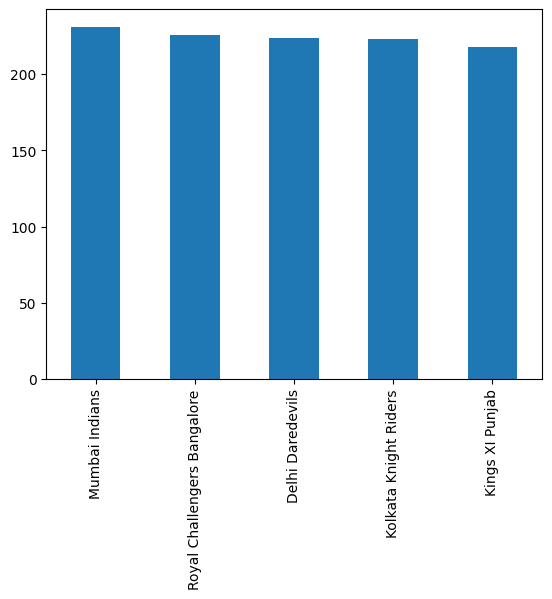

In [143]:
(ipl['Team1'].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending = False).head(5).plot(kind = "bar")

###`Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [144]:
ipl.Team1.value_counts()

,count
Team1,
Royal Challengers Bangalore,126
Delhi Daredevils,114
Mumbai Indians,112
Chennai Super Kings,111
Kings XI Punjab,110
Kolkata Knight Riders,105
Rajasthan Royals,89
Sunrisers Hyderabad,69
Deccan Chargers,39


In [145]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [146]:
m1 = (ipl.Team2 == "Mumbai Indians") |(ipl.Team2 == "Mumbai Indians")
m2 = ipl.WinningTeam!="Mumbai Indians"
m = ipl[m1&m2].Player_of_Match.reset_index()
m.groupby('Player_of_Match')['Player_of_Match'].count().sort_values(ascending =False).head()

,Player_of_Match
Player_of_Match,
SK Raina,4
KC Sangakkara,3
V Sehwag,3
KL Rahul,2
SPD Smith,2


###`Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [160]:
def records(team1,team2):
  m1 = (ipl.Team1 == team1 )| (ipl.Team2 == team1)
  m2 = (ipl.Team1 == team2 )| (ipl.Team2 == team2)
  m = ipl[m1&m2]
  print(m.WinningTeam.value_counts())
  print(m.Player_of_Match.value_counts().head())

In [161]:
records('Kolkata Knight Riders','Chennai Super Kings')

WinningTeam
Chennai Super Kings      17
Kolkata Knight Riders     9
Name: count, dtype: int64
Player_of_Match
RA Jadeja       3
F du Plessis    2
MEK Hussey      2
UT Yadav        1
RA Tripathi     1
Name: count, dtype: int64


### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



In [167]:
ipl[(ipl['Team1'] == 'Kolkata Knight Riders')|(ipl['Team2'] == 'Kolkata Knight Riders')].groupby('City')['City'].count().sort_values(ascending= False).head(7)

,City
City,
Kolkata,74
Mumbai,23
Abu Dhabi,14
Chennai,12
Bangalore,11
Delhi,10
Pune,9


In [187]:
ipl.dropna(inplace = True)

### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [188]:
ipl[((ipl.Team1 == "Mumbai Indians")|(ipl.Team2 == "Mumbai Indians")) &(ipl.Season ==2011)]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2


In [172]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [177]:
ipl.Season == 2022

,Season
0,False
1,False
2,False
3,False
4,False
...,...
945,False
946,False
947,False
948,False


In [178]:
ipl.Season.value_counts()

,count
Season,
2013,76
2012,74
2022,74
2011,73
2019,60
2021,60
2020/21,60
2009/10,60
2016,60


In [190]:
ipl['Season'] = pd.to_numeric(ipl['Season'], errors='coerce')



In [193]:
ipl[ipl['Season'] == 2022]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2


In [185]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    